In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics
import warnings



warnings.filterwarnings('ignore')
import statsmodels

In [34]:
# wczytanie zrobionej ramki danych z poprzedniego etapu
train = pd.read_csv("summary.csv")

In [35]:
print(train.head())

                       cellid  avg_region1_length  avg_region2_length  \
0  SCG0088_AAAGGACGTTAACGGC-1           89.425013          117.117021   
1  SCG0088_AAATCCGGTGACATAT-1           80.616243          112.613549   
2  SCG0088_AACAGCAAGACAGGCG-1           82.671569          115.306781   
3  SCG0088_AACATCATCAGGTTTA-1           87.414566          116.915349   
4  SCG0088_AACCTTAAGCTGCACA-1           80.333188          109.388066   

   median_region1_length  median_region2_length  max_region1_length  \
0                   82.0                  148.0                 204   
1                   57.0                  148.0                 172   
2                   57.0                  150.0                 168   
3                   70.0                  149.0                 177   
4                   60.0                  141.0                 170   

   max_region2_length  same_chr_contacts  total_contacts phase  ...  \
0                 182               3179            3854    G1 

In [36]:
file_path2 = "test_data_2000.csv"
test = pd.read_csv(file_path2, sep=",")
test.head()

,cellid,phase,order_within_phase,order
0,SCG0089_CTTATGTTCCCGCCTA-1,NaN,NaN,NaN
1,SCG0093_AGAACCGCACAGCCAT-1,NaN,NaN,NaN
2,SCG0090_CCAGGATGTGCTCACC-1,NaN,NaN,NaN
3,SCG0089_TACCTTTAGCACTTGG-1,NaN,NaN,NaN
4,SCG0092_TGATCAGGTTTGAGGC-1,NaN,NaN,NaN


In [37]:
# ramka danych zrobiona w poprzednim etapie zawiera wiersze ktre mają wartości NaN w kolumnie phase
# te wiersze całkowicie się pokrywają z tymi które są w ramce danych test
test = test.merge(train, on='cellid', how='left')
test['phase'] = test['phase_y']
test = test.drop(columns=['phase_x', 'phase_y'])

In [38]:
print(test['phase'].unique())

[nan]


In [39]:
train=train.dropna() #usuwamy wiersze które odnoszą się do zbioru testowego

In [40]:
# mapowanie etykiet kategorii na wartości liczbowe
phase_mapping = {'G1': 0, 'S': 1, 'G2M': 2}
train['phase'] = train['phase'].map(phase_mapping)

In [41]:
train=train.drop(columns=["cellid"])

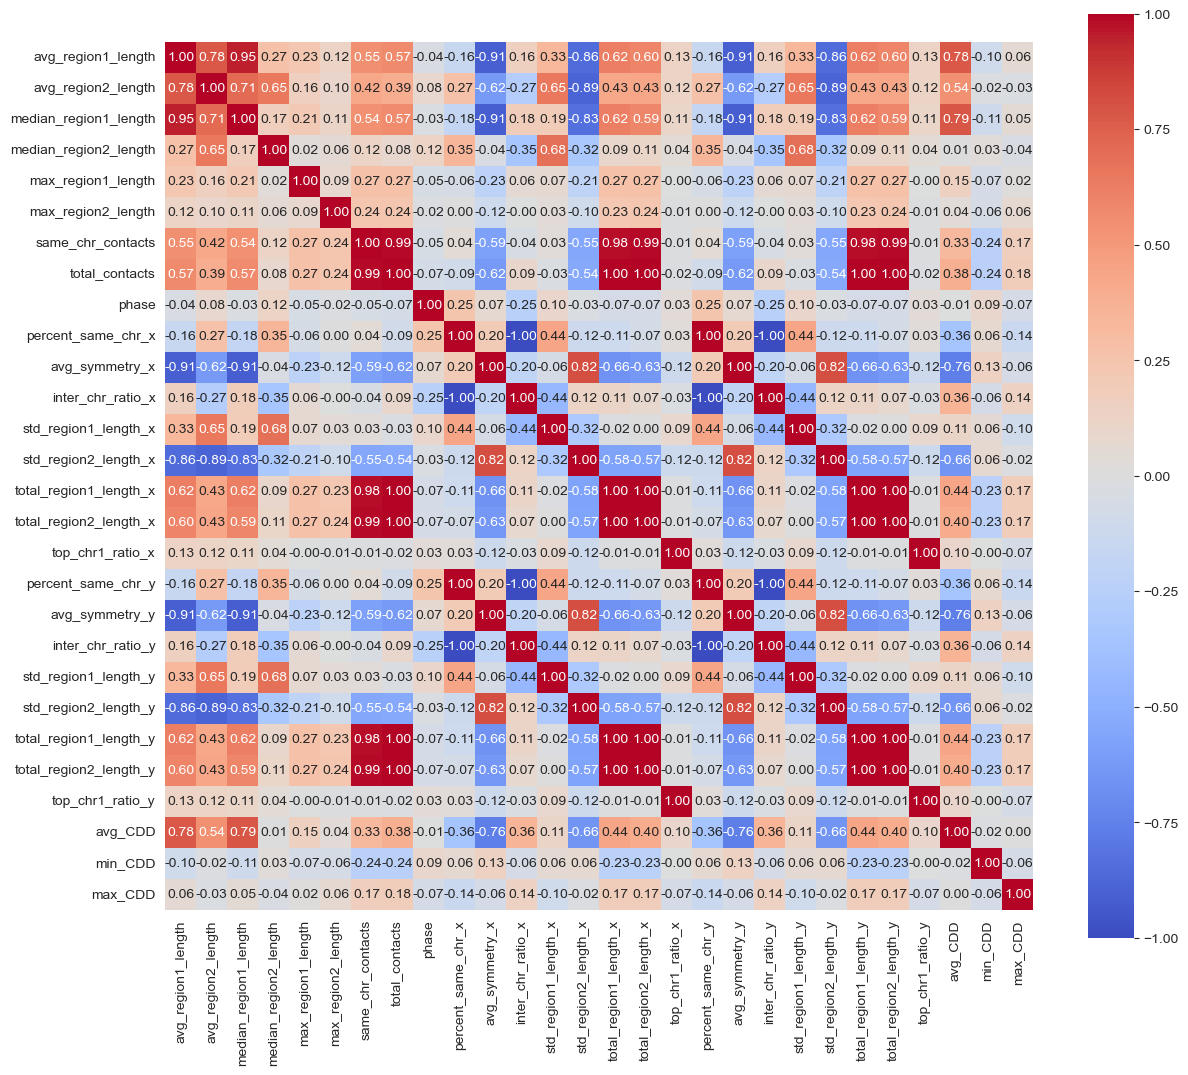

In [42]:
# tworzenie macierzy korelacji dla wykrycie zmiennych silnie skorelowanych
plt.figure(figsize=(14, 12))
corr = train.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.show()

In [43]:
# automatyczne usunięcie cech, które są zbyt silnie skorelowane ze sobą
threshold = 0.9   # próg korelacji

# tworzenie macierzy trójkątna bez przekątnej
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool))

# lista cech do usunięcia
to_drop = [column for column in upper.columns if any(upper[column].abs() > threshold)]

print("Cechy do usunięcia:", to_drop)

# nowy zbiór danych po usunięciu skorelowanych cech
train = train.drop(columns=to_drop)

Cechy do usunięcia: ['median_region1_length', 'total_contacts', 'avg_symmetry_x', 'inter_chr_ratio_x', 'total_region1_length_x', 'total_region2_length_x', 'percent_same_chr_y', 'avg_symmetry_y', 'inter_chr_ratio_y', 'std_region1_length_y', 'std_region2_length_y', 'total_region1_length_y', 'total_region2_length_y', 'top_chr1_ratio_y']


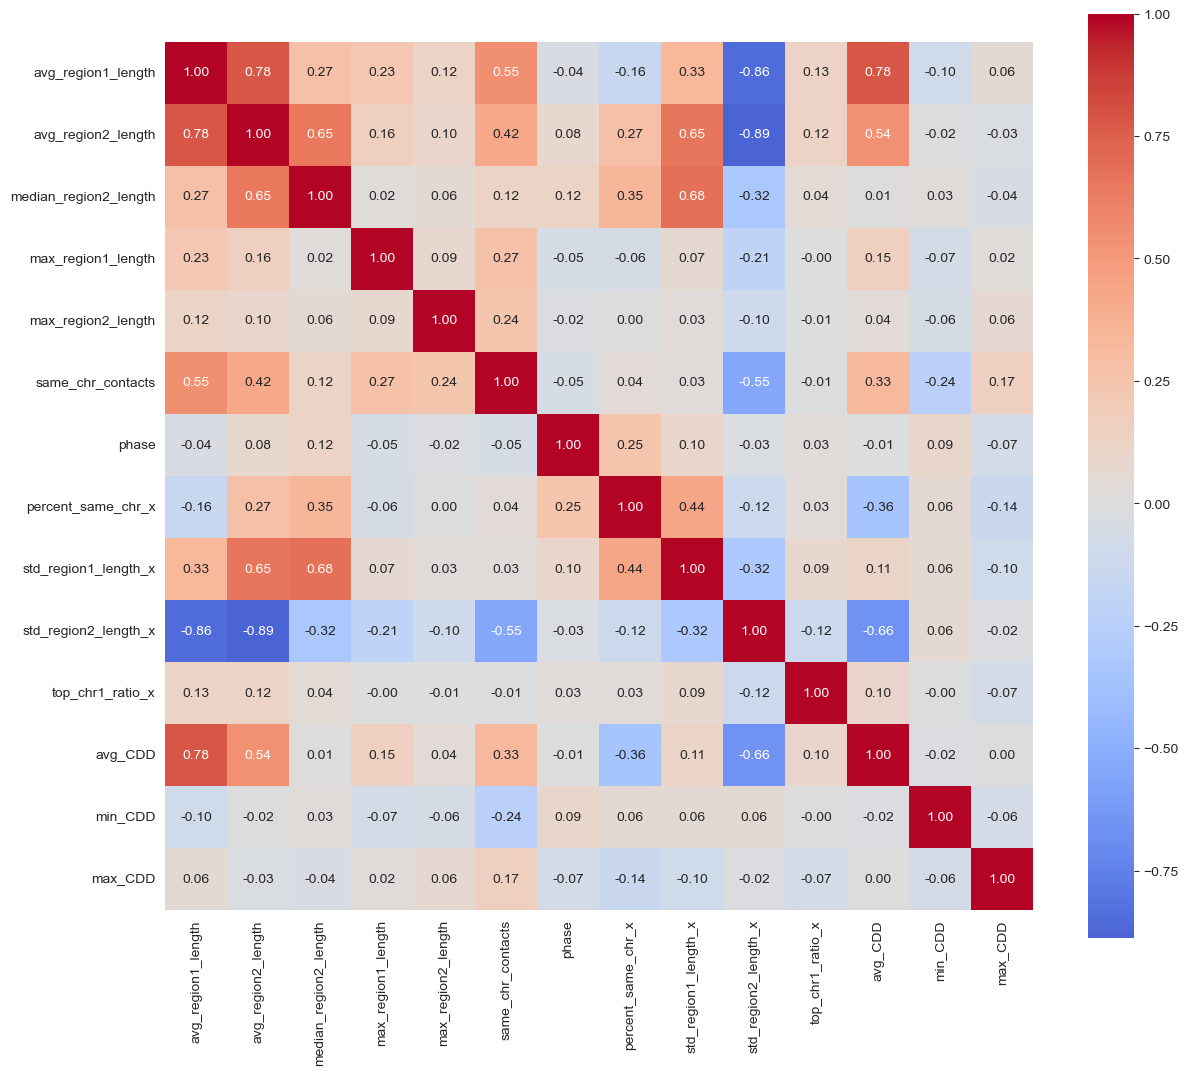

In [44]:
# macierz korelacji po usunięciu powyższych cech
plt.figure(figsize=(14, 12))
corr = train.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.show()

In [45]:
# podział danych na zbiór treningowy i walidacyjny
from sklearn.model_selection import train_test_split

X = train.drop(columns=['phase'])
y = train[['phase']]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
y['phase'].value_counts()

phase
2    810
0    394
1    297
Name: count, dtype: int64

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
rf.fit(X_train, y_train.values.ravel())

y_pred = rf.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred, target_names=['G1', 'S', 'G2M']))

# model poprawnie klasyfikuje 58.8% przykładów ze zbioru walidacyjnego
# G2M jest klasyfikowana dobrze: f1 = 0.72
# S jest rozpoznawana bardzo słabo: recall = 0.03
# model dobrze wykrywa klasę G2M, która dominuje liczebnie, potrzeba w oversamplingu klas G1 i S, które są znacząco mniejsze od G2M

Accuracy: 0.5880398671096345

Classification Report:
               precision    recall  f1-score   support

          G1       0.53      0.43      0.47        82
           S       0.29      0.03      0.06        60
         G2M       0.61      0.88      0.72       159

    accuracy                           0.59       301
   macro avg       0.48      0.45      0.42       301
weighted avg       0.53      0.59      0.52       301



In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train.values.ravel())

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
rf_smote.fit(X_resampled, y_resampled)

y_pred = rf_smote.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred, target_names=['G1', 'S', 'G2M']))

# próba oversamlingu metodą SMOTE, która tworzy sztuczne przykłady klasy mniejszościowej
# to prawie nie poprawiło wyniku

Accuracy: 0.5481727574750831

Classification Report:
               precision    recall  f1-score   support

          G1       0.54      0.55      0.55        82
           S       0.18      0.13      0.15        60
         G2M       0.64      0.70      0.67       159

    accuracy                           0.55       301
   macro avg       0.46      0.46      0.46       301
weighted avg       0.52      0.55      0.53       301



In [ ]:
# poszukiwanie najlepszych hiperparametrów metodą GridSearch
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 800],
    'max_depth': [None, 10],
    'min_samples_split': [2, 10],
    'criterion' : ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train.values.ravel())
print("Najlepsze parametry:", grid.best_params_)

Najlepsze parametry: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}


In [ ]:
# ustawienie najlepszych hiperparametrów
best_rf = RandomForestClassifier(
    criterion = 'gini',
    max_depth=None,
    max_features='sqrt',
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

best_rf.fit(X_train, y_train.values.ravel())

y_pred = best_rf.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred, target_names=['G1', 'S', 'G2M']))

# w wyniku model osiągnął około 60% trafności
# dalej niedobrze radzi z klasą S i skupia się głównie na G2M
# potrzeba w testowaniu innego modelu

Accuracy: 0.5980066445182725

Classification Report:
               precision    recall  f1-score   support

          G1       0.54      0.44      0.48        82
           S       0.60      0.05      0.09        60
         G2M       0.62      0.89      0.73       159

    accuracy                           0.60       301
   macro avg       0.58      0.46      0.43       301
weighted avg       0.59      0.60      0.53       301



In [ ]:
# próba modelu na zbiorze testowym
X_test = test[X_train.columns]
y_test_pred = best_rf.predict(X_test)

XGBoost

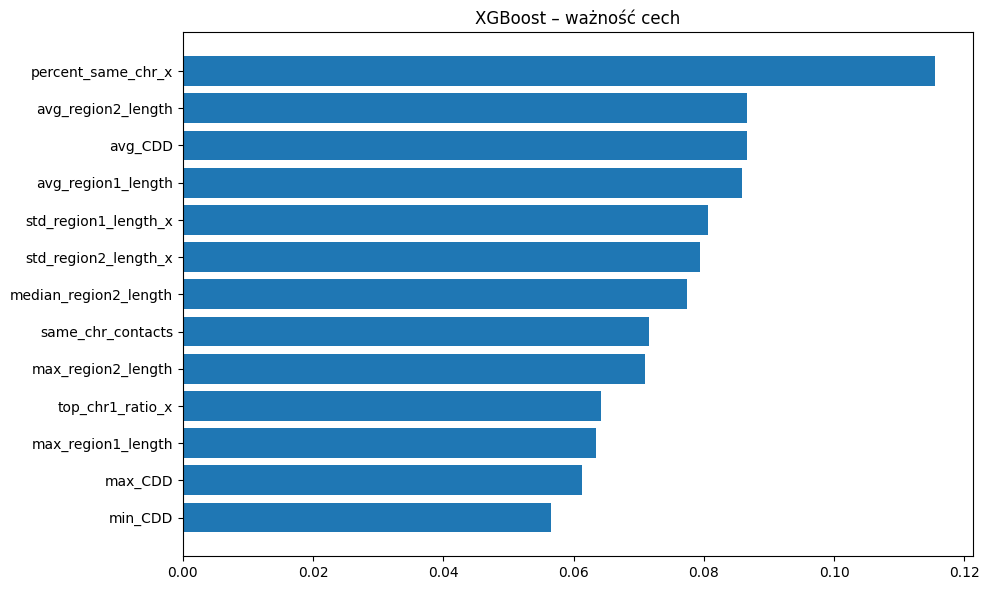

In [ ]:
#waznosc cech
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softmax',
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(X_train, y_train.values.ravel())

importances = xgb.feature_importances_
features = X_train.columns

sorted_idx = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], importances[sorted_idx])
plt.title("XGBoost – ważność cech")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train.values.ravel())
y_pred = xgb.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.5913621262458472

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.46      0.49        82
           1       0.30      0.13      0.18        60
           2       0.66      0.83      0.73       159

    accuracy                           0.59       301
   macro avg       0.49      0.48      0.47       301
weighted avg       0.55      0.59      0.56       301



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_base = XGBClassifier(
    objective='multi:softmax',
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train.values.ravel())

print("Best parameters:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Accuracy: 0.6079734219269103

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.43      0.48        82
           1       0.43      0.10      0.16        60
           2       0.63      0.89      0.74       159

    accuracy                           0.61       301
   macro avg       0.54      0.47      0.46       301
weighted avg       0.57      0.61      0.56       301



In [15]:
#obnizenie bledu kladyfikacji klasy 1
from sklearn.utils import compute_class_weight

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train.values.ravel())
print(dict(zip(np.unique(y_train), weights)))

{np.int64(0): np.float64(1.2820512820512822), np.int64(1): np.float64(1.6877637130801688), np.int64(2): np.float64(0.6144393241167435)}


In [16]:
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42,scale_pos_weight=4.06,objective='multi:softprob')
xgb.fit(X_train, y_train.values.ravel())
y_pred = xgb.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
scale_pos_weight=4.06

Accuracy: 0.6046511627906976

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.51      0.55        82
           1       0.31      0.15      0.20        60
           2       0.66      0.82      0.73       159

    accuracy                           0.60       301
   macro avg       0.52      0.50      0.49       301
weighted avg       0.57      0.60      0.57       301



In [17]:
#oversampling klasy 1
from imblearn.over_sampling import SMOTE
from collections import Counter

# Sprawdzenie oryginalnego rozkładu klas
print("Przed SMOTE:", Counter(y))

smote = SMOTE(sampling_strategy={1: 800}, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Sprawdzenie nowego rozkładu klas
print("Po SMOTE:", Counter(y_resampled))

Przed SMOTE: Counter({'phase': 1})
Po SMOTE: Counter({'phase': 1})


In [18]:
# 2. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.5, random_state=42, stratify=y_resampled
)

# 3. Trening modelu XGBoost
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=4,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# 4. Ewaluacja modelu
y_pred = model.predict(X_test)
print("Raport klasyfikacji:\n")
print(classification_report(y_test, y_pred, digits=3))

Raport klasyfikacji:

              precision    recall  f1-score   support

           0      0.514     0.386     0.441       197
           1      0.699     0.680     0.689       400
           2      0.624     0.716     0.667       405

    accuracy                          0.637      1002
   macro avg      0.612     0.594     0.599      1002
weighted avg      0.632     0.637     0.631      1002



In [19]:
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.948
Test Accuracy: 0.637


In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_resampled, y_resampled, cv=5, scoring='accuracy')
print("Cross-val accuracy (średnia):", scores.mean())
print("Wyniki w foldach:", scores)

Cross-val accuracy (średnia): 0.6492468827930175
Wyniki w foldach: [0.46633416 0.52618454 0.77057357 0.74314214 0.74      ]


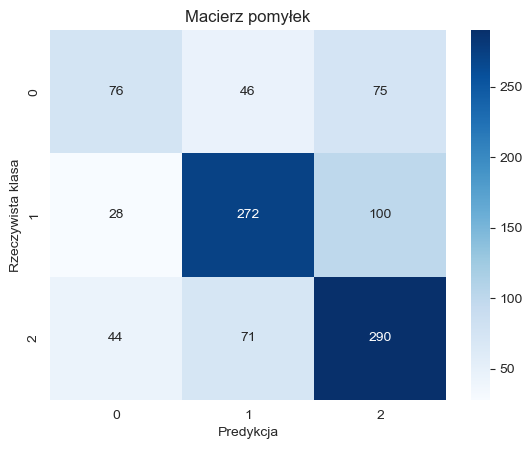

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek")
plt.show()

# SVM

In [57]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
svm = SVC()
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}
grid = GridSearchCV(svm, param_grid, scoring='accuracy', cv=2, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train.values.ravel())
print("Best parameters:", grid.best_params_)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best parameters: {'C': 0.1, 'gamma': 'scale'}


Raport klasyfikacji:

              precision    recall  f1-score   support

           0      0.000     0.000     0.000       197
           1      0.000     0.000     0.000       400
           2      0.404     1.000     0.576       405

    accuracy                          0.404      1002
   macro avg      0.135     0.333     0.192      1002
weighted avg      0.163     0.404     0.233      1002

Train Accuracy: 0.540
Test Accuracy: 0.404


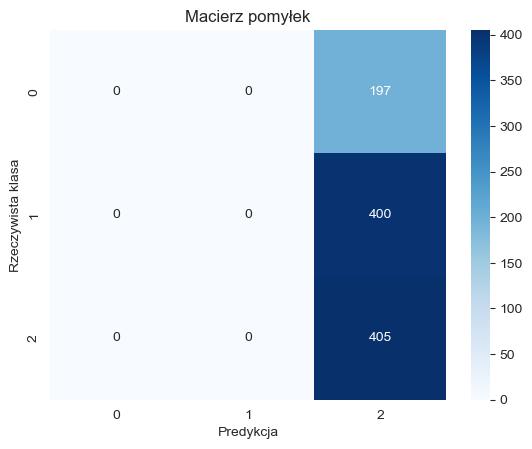

In [59]:
best_svm = grid.best_estimator_
best_svm.fit(X_train, y_train.values.ravel())
y_pred = best_svm.predict(X_test)

print("Raport klasyfikacji:\n")
print(classification_report(y_test, y_pred, digits=3))

y_train_pred = best_svm.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek")
plt.show()

Model słabo klasyfikuje klasę 0, która jest mniejszością

In [60]:
# próba z standaryzacją
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma='scale', C=1))
svm.fit(X_train, y_train.values.ravel())
y_pred = svm.predict(X_val)

print("Raport klasyfikacji:\n")
print(classification_report(y_val, y_pred, digits=3))

Raport klasyfikacji:

              precision    recall  f1-score   support

           0      0.625     0.366     0.462        82
           1      0.000     0.000     0.000        60
           2      0.601     0.956     0.738       159

    accuracy                          0.605       301
   macro avg      0.409     0.441     0.400       301
weighted avg      0.488     0.605     0.516       301



Train Accuracy: 0.540
Test Accuracy: 0.404


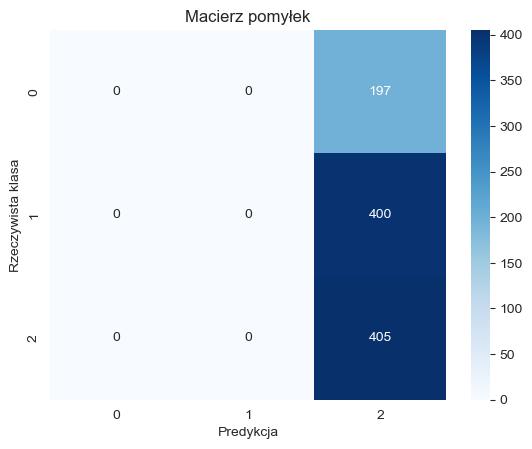

In [61]:
best_svm = grid.best_estimator_
best_svm.fit(X_train, y_train.values.ravel())
y_pred = best_svm.predict(X_test)

y_train_pred = best_svm.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek")
plt.show()

In [62]:
svm = make_pipeline(StandardScaler(), SVC())
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto']
}
grid = GridSearchCV(svm, param_grid, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train.values.ravel())
print("Best parameters:", grid.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters: {'svc__C': 1, 'svc__gamma': 'scale'}


Raport klasyfikacji:

              precision    recall  f1-score   support

           0      0.522     0.416     0.463       197
           1      1.000     0.003     0.005       400
           2      0.457     0.953     0.618       405

    accuracy                          0.468      1002
   macro avg      0.660     0.457     0.362      1002
weighted avg      0.687     0.468     0.343      1002

Train Accuracy: 0.620
Test Accuracy: 0.468


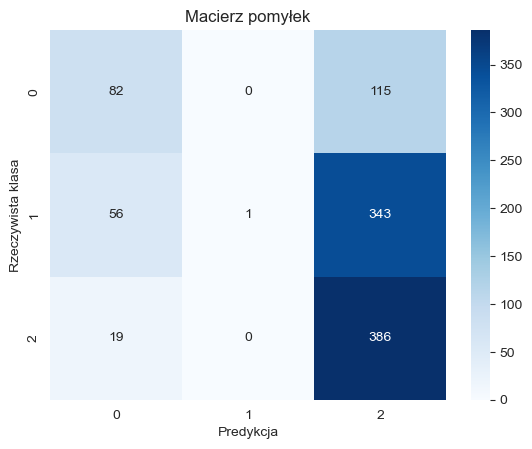

In [63]:
best_svm = grid.best_estimator_
best_svm.fit(X_train, y_train.values.ravel())
y_pred = best_svm.predict(X_test)

print("Raport klasyfikacji:\n")
print(classification_report(y_test, y_pred, digits=3))

y_train_pred = best_svm.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek")
plt.show()

In [64]:
#robimy gridsearch bliżej 10
svm = make_pipeline(StandardScaler(), SVC(gamma='scale'))
param_grid = {
    'svc__C': [9.5, 9.6, 9.7, 9.8, 9.9, 10, 10.1, 10.2, 10.3, 10.4, 10.5]
}
grid = GridSearchCV(svm, param_grid, scoring='accuracy', cv=2, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train.values.ravel())
print("Best parameters:", grid.best_params_)

Fitting 2 folds for each of 11 candidates, totalling 22 fits
Best parameters: {'svc__C': 9.5}


Raport klasyfikacji:

              precision    recall  f1-score   support

           0      0.697     0.701     0.699       197
           1      0.946     0.305     0.461       400
           2      0.578     0.963     0.722       405

    accuracy                          0.649      1002
   macro avg      0.740     0.656     0.627      1002
weighted avg      0.748     0.649     0.613      1002

Train Accuracy: 0.764
Test Accuracy: 0.649


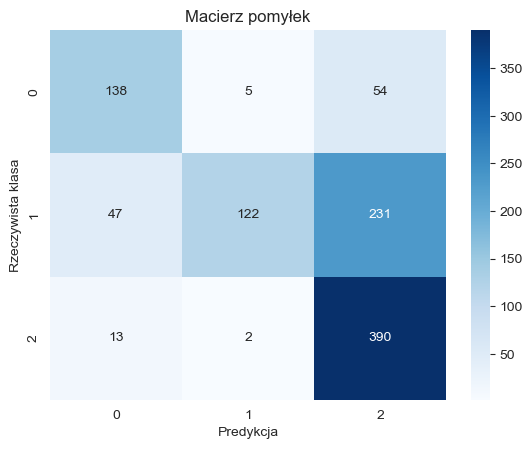

In [65]:
best_svm = grid.best_estimator_
best_svm.fit(X_train, y_train.values.ravel())
y_pred = best_svm.predict(X_test)

print("Raport klasyfikacji:\n")
print(classification_report(y_test, y_pred, digits=3))

y_train_pred = best_svm.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek")
plt.show()

In [119]:
#Model sieci neuronowej (MLP)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

# standaryzacja danych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# konwersja y na one-hot encoding
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3)

In [120]:
# budowa modelu
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))  # 3 klasy: G1, S, G2M

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# trenowanie modelu
history = model.fit(X_train_scaled, y_train_cat, epochs=50, batch_size=32,
                    validation_data=(X_val_scaled, y_val_cat), verbose=1)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4764 - loss: 1.0333 - val_accuracy: 0.5349 - val_loss: 1.0059
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5810 - loss: 0.9392 - val_accuracy: 0.5515 - val_loss: 0.9839
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5671 - loss: 0.9377 - val_accuracy: 0.5382 - val_loss: 0.9729
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5604 - loss: 0.9364 - val_accuracy: 0.5581 - val_loss: 0.9679
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5841 - loss: 0.9200 - val_accuracy: 0.5482 - val_loss: 0.9720
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5939 - loss: 0.9038 - val_accuracy: 0.5615 - val_loss: 0.9692
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5557 - loss: 0.9273 - val_accuracy: 0.5581 - val_loss: 0.9627
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5751 - loss: 0.9148 - val_accuracy: 0.5648 - val_loss:

Test Accuracy: 0.561
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Raport klasyfikacji (NN):

              precision    recall  f1-score   support

           0      0.517     0.366     0.429        82
           1      0.286     0.100     0.148        60
           2      0.599     0.836     0.698       159

    accuracy                          0.561       301
   macro avg      0.467     0.434     0.425       301
weighted avg      0.514     0.561     0.515       301



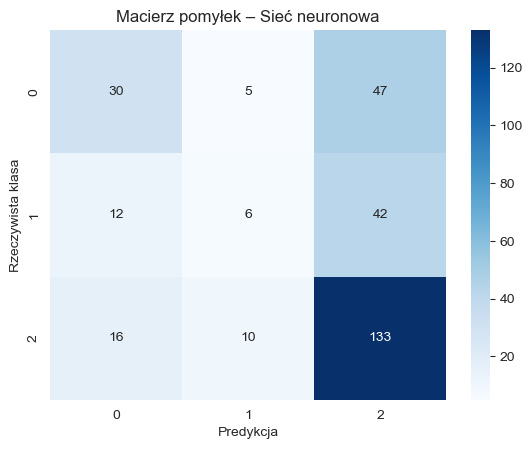

In [121]:
# ocena modelu
loss, accuracy = model.evaluate(X_val_scaled, y_val_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.3f}")

# predykcje
y_pred_nn = model.predict(X_val_scaled)
y_pred_nn_classes = np.argmax(y_pred_nn, axis=1)

# raport
from sklearn.metrics import classification_report, confusion_matrix
print("Raport klasyfikacji (NN):\n")
print(classification_report(y_val, y_pred_nn_classes, digits=3))

# macierz pomyłek
cm = confusion_matrix(y_val, y_pred_nn_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek – Sieć neuronowa")
plt.show()

# Najlepszy model

In [47]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=4,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
X_train = train.drop(columns=['phase'])
y_train = train['phase']

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_class=3, ...)

In [77]:
model = best_svm

In [78]:
test = pd.read_csv("test_data_2000.csv")[['cellid']].values.ravel()
summary = pd.read_csv("summary.csv")
summary = summary.loc[summary['cellid'].isin(test), :]
summary = summary.drop(columns=to_drop)
summary = summary.drop(columns=['cellid', 'phase'])

In [79]:
y_pred = model.predict(summary)

In [80]:
y_pred

array([0, 0, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 2, 2, 0, 2, 0,
       2, 0, 2, 2, 1, 1, 0, 2, 1, 0, 1, 2, 2, 2, 2, 2, 0, 2, 0, 0, 2, 2,
       2, 2, 2, 2, 0, 2, 1, 1, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 0, 0, 2, 0, 2, 2, 2, 2, 2, 2, 0, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 2, 1, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 2, 2, 0, 2, 0, 0,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 0, 2, 1, 2, 2, 2, 0, 2,
       0, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 2, 0, 1, 1, 2, 2, 0, 2, 2, 2, 1, 0, 2, 0, 2, 2,
       2, 0, 2, 0, 2, 1, 0, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2,
       2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 0, 2, 0, 0, 0, 1, 1, 2, 2, 2, 2, 2,
       2, 2, 1, 1, 2, 2, 2, 0, 2, 1, 0, 1, 0, 2, 2,

In [81]:
test = pd.read_csv("test_data_2000.csv")
test['phase'] = y_pred
phase_mapping = {0 : 'G1', 1 : 'S', 2 : 'G2M'}
test['phase'] = test['phase'].map(phase_mapping)

In [82]:
test

,cellid,phase,order_within_phase,order
0,SCG0089_CTTATGTTCCCGCCTA-1,G1,NaN,NaN
1,SCG0093_AGAACCGCACAGCCAT-1,G1,NaN,NaN
2,SCG0090_CCAGGATGTGCTCACC-1,G2M,NaN,NaN
3,SCG0089_TACCTTTAGCACTTGG-1,G2M,NaN,NaN
4,SCG0092_TGATCAGGTTTGAGGC-1,G1,NaN,NaN
...,...,...,...,...
375,SCG0089_TGAGCCGGTAACGGGA-1,G1,NaN,NaN
376,SCG0093_ACTAAAGCACCTGCCT-1,G2M,NaN,NaN
377,SCG0091_TAGCATATCATTGACA-1,G2M,NaN,NaN
378,SCG0091_ATGTTGTCAACCCTAA-1,G1,NaN,NaN


In [73]:
y_pred = model.predict(train.drop(columns=['phase']))

In [74]:
train['phase_pred'] = y_pred
phase_mapping = {0 : 'G1', 1 : 'S', 2 : 'G2M'}
train['phase_pred'] = train['phase_pred'].map(phase_mapping)
train['phase_pred'] == df['phase']

0        True
1        True
2        True
3       False
5       False
        ...  
1874     True
1875     True
1876     True
1878     True
1880    False
Length: 1501, dtype: bool

In [75]:
df = pd.read_csv("summary.csv").dropna()
df

,cellid,avg_region1_length,avg_region2_length,median_region1_length,median_region2_length,max_region1_length,max_region2_length,same_chr_contacts,total_contacts,phase,...,avg_symmetry_y,inter_chr_ratio_y,std_region1_length_y,std_region2_length_y,total_region1_length_y,total_region2_length_y,top_chr1_ratio_y,avg_CDD,min_CDD,max_CDD
0,SCG0088_AAAGGACGTTAACGGC-1,89.425013,117.117021,82.0,148.0,204,182,3179,3854,G1,...,67.493773,0.175143,54.436008,46.085952,344644,451369,0.062792,85.231628,11.0,138.0
1,SCG0088_AAATCCGGTGACATAT-1,80.616243,112.613549,57.0,148.0,172,175,2296,2598,S,...,73.302925,0.116243,52.872011,48.563223,209441,292570,0.070824,76.904854,1.0,136.0
2,SCG0088_AACAGCAAGACAGGCG-1,82.671569,115.306781,57.0,150.0,168,200,2165,2448,G1,...,72.911356,0.115605,54.767144,48.730733,202380,282271,0.106618,75.102533,1.0,137.0
3,SCG0088_AACATCATCAGGTTTA-1,87.414566,116.915349,70.0,149.0,177,189,5228,5753,S,...,67.384669,0.091257,55.014921,46.709489,502896,672614,0.075613,75.700400,1.0,137.0
5,SCG0088_AACTAGCTCCAGGTTG-1,84.284431,115.329716,60.0,150.0,182,194,2266,2672,S,...,73.072979,0.151946,54.713918,48.284826,225208,308161,0.120135,78.502434,11.0,137.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1874,SCG0093_TTTGACCGTCAATAGT-1,83.645108,114.945688,64.0,147.0,172,195,2154,2412,G2M,...,71.438226,0.106965,52.750904,46.382965,201752,277249,0.107380,76.296020,22.0,138.0
1875,SCG0093_TTTGACCGTCAGGCCA-1,82.298232,113.550207,61.0,148.0,180,187,2267,2659,G2M,...,72.001128,0.147424,53.441284,47.526801,218831,301930,0.093644,76.490587,1.0,138.0
1876,SCG0093_TTTGACTTCAAGGACA-1,84.366097,116.336182,62.0,150.0,202,184,1792,2106,G2M,...,71.969136,0.149098,54.565730,47.672138,177675,245004,0.089269,78.461538,21.0,137.0
1878,SCG0093_TTTGCGGAGGATGATG-1,81.184297,109.548190,58.0,145.0,172,183,1787,2127,G1,...,73.464974,0.159850,53.327251,49.655534,172679,233009,0.103432,76.395108,21.0,136.0


In [76]:
pred = pd.read_csv("predicted.csv")
pred['phase'] == test['phase']

0      False
1      False
2       True
3      False
4       True
       ...  
375     True
376     True
377     True
378     True
379    False
Name: phase, Length: 380, dtype: bool

In [83]:
test.to_csv("pred.csv", index=False)